<a href="https://colab.research.google.com/github/dhanushv282004/Olympics-Data-Analysis/blob/main/Olympics_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***Project 2- Olympics Data Analysis***

**Objective**
1. Analyze Olympic trends (1976–2008)
2. Identify top-performing countries and athletes
3. Explore gender distribution
4. Predict medal wins using ML

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load the dataset
df = pd.read_csv('/content/Summer-Olympic-medals-1976-to-2008 (1).csv',encoding='ISO-8859-1')
# Use encoding='ISO-8859-1' in read_csv() to correctly read files that are not in UTF-8 format and avoid Unicode decoding errors.

# Preview the data
df.head()

# Data Cleaning
df.isnull().sum()
df = df.dropna()
df.info()



<class 'pandas.core.frame.DataFrame'>
Index: 15316 entries, 0 to 15432
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   City          15316 non-null  object 
 1   Year          15316 non-null  float64
 2   Sport         15316 non-null  object 
 3   Discipline    15316 non-null  object 
 4   Event         15316 non-null  object 
 5   Athlete       15316 non-null  object 
 6   Gender        15316 non-null  object 
 7   Country_Code  15316 non-null  object 
 8   Country       15316 non-null  object 
 9   Event_gender  15316 non-null  object 
 10  Medal         15316 non-null  object 
dtypes: float64(1), object(10)
memory usage: 1.4+ MB


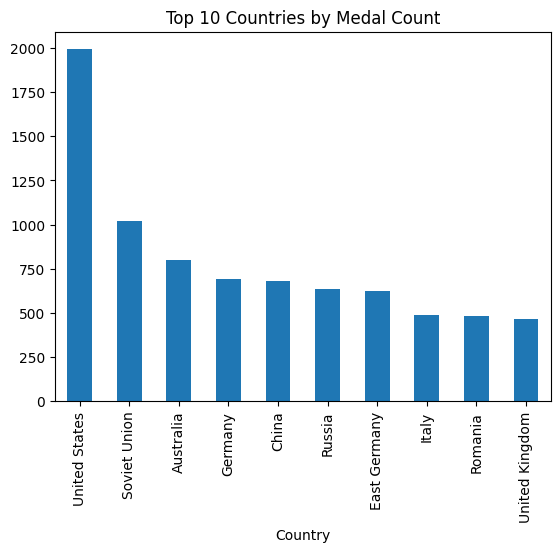

In [ ]:
# Medals by country
medals_by_country = df['Country'].value_counts().head(10)
medals_by_country.plot(kind='bar', title='Top 10 Countries by Medal Count')
plt.show()


**Exploratory Data Analysis**

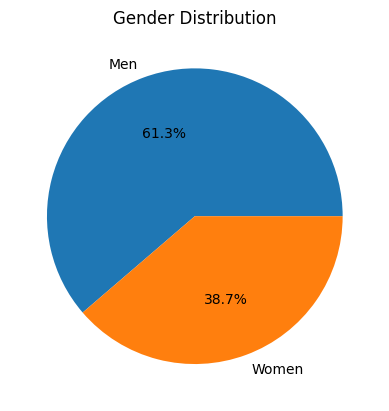

In [ ]:
# Gender distribution
df['Gender'].value_counts().plot.pie(autopct='%1.1f%%', title='Gender Distribution')
plt.ylabel('')
plt.show()


**Predictive Modeling**

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier

df.columns = df.columns.str.strip()

df['Medal'] = df['Medal'].astype(str).str.strip().str.capitalize()
df['Medal'] = df['Medal'].map({'Bronze': 0, 'Silver': 1, 'Gold': 2})

df = df.dropna(subset=['Medal'])

# -------------------------------
# FEATURE ENGINEERING
# -------------------------------

X = pd.get_dummies(df[['Country', 'Sport', 'Gender']])
y = df['Medal'].astype(int)

# -------------------------------
# TRAIN-TEST SPLIT
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# -------------------------------
# MODEL (BETTER THAN LOGISTIC)
# -------------------------------
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

# -------------------------------
# PREDICTION
# -------------------------------
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.5331882480957563

Classification Report:
               precision    recall  f1-score   support

           0       0.53      0.53      0.53      1529
           1       0.54      0.47      0.50      1511
           2       0.53      0.59      0.56      1555

    accuracy                           0.53      4595
   macro avg       0.53      0.53      0.53      4595
weighted avg       0.53      0.53      0.53      4595



**Conclusion**
1. USA and Russia dominate medal counts
2. Gender inequality in event participation
3. ML model shows basic prediction power